# MCBM Recall Gap Analysis — γ sweep (CUB-200-2011)

This notebook extends the matched-pair recall-gap analysis from recall.ipynb to
**Minimal Concept Bottleneck Models (MCBM)** (Almudévar et al., arXiv:2506.04877).

MCBM adds an Information Bottleneck (IB) penalty that forces each concept representation
z_j to be a *minimal* sufficient statistic for concept c_j, suppressing species identity
leakage.

**Central question:** As γ (IB penalty strength) increases, does the recall gap decrease?
γ=0.0 recovers standard CBM (sanity check — results should be close to cbm_species.csv).

γ values evaluated: 0.0, 0.1, 0.5, 1.0, 5.0
Feature dirs: features/resnet50_mcbm_gamma{γ}/
Output CSVs: mcbm_species_gamma{γ}.csv

For each attribute:

1. Train a linear probe on top of frozen visual features.
2. Evaluate the probe on held-out test images.
3. Group test images by species.
4. For pairs of species:
   - Subsample images so that both species have the same number of
     attribute-positive and attribute-negative examples.
   - Compute recall on attribute-positive images for each species.
5. Measure the recall gap between species.

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn


## 0. Configuration

Set `ROOT` to the Adroit project root (`/scratch/network/cr7998/cv_emergence_project`).
All other paths derive from it:

- `CUB` — CUB-200-2011 dataset root (images, attributes, metadata)
- `ATTR_TXT` — maps integer attribute IDs → names like `has_primary_color::yellow`
- `MCBM_FEATS[γ]` — pre-computed ResNet-50 backbone features for MCBM trained at IB
  strength γ. Extracted at 18 fine-grained probe points (conv1, layer1.0–2,
  layer2.0–3, layer3.0–5, layer4.0–2, avgpool).
  Produced by `run_mcbm_extract_adroit.sh` on Adroit.

**γ sweep:** `0.0` (= standard CBM, sanity check), `0.1`, `0.5`, `1.0`, `5.0`

In [2]:
ROOT = Path("/scratch/network/cr7998/cv_emergence_project")
CUB  = ROOT / "data" / "CUB_200_2011"

ATTR_TXT = ROOT / "data" / "attributes.txt"   # attr_id -> attr_name like has_primary_color::yellow

# MCBM feature directories — one per gamma value
GAMMAS = [0.0, 0.1, 0.5, 1.0, 5.0]
MCBM_FEATS = {g: ROOT / "features" / f"resnet50_mcbm_gamma{g}" for g in GAMMAS}

assert CUB.exists(), f"Missing CUB folder: {CUB}"
assert ATTR_TXT.exists(), f"Missing attributes.txt: {ATTR_TXT}"
for g, d in MCBM_FEATS.items():
    assert d.exists(), f"Missing MCBM features for gamma={g}: {d}"

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [3]:
def load_species_maps(cub_root: Path):
    """
    Loads species ID to name mappings from classes.txt.
    Also produces a prettified version for printing.
    """
    classes = pd.read_csv(
        cub_root / "classes.txt",
        sep=r"\s+",
        header=None,
        names=["species_id", "class_name"],
        engine="python"
    )

    def pretty(name: str) -> str:
        # Example: "001.Black_footed_Albatross" -> "Black footed albatross"
        return name.split(".", 1)[-1].replace("_", " ")

    id_to_pretty = {
        int(r.species_id): pretty(r.class_name)
        for _, r in classes.iterrows()
    }

    return id_to_pretty

species_id_to_name = load_species_maps(CUB)

def spname(sid: int) -> str:
    return species_id_to_name.get(int(sid), f"species_{sid}")


In [4]:
def load_meta(cub_root: Path) -> pd.DataFrame:
    """
    Returns a dataframe mapping each image to:
    - species ID
    - train/test split
    """
    img_species = pd.read_csv(
        cub_root / "image_class_labels.txt",
        sep=r"\s+",
        header=None,
        names=["image_id", "species_id"],
        engine="python"
    )

    split_df = pd.read_csv(
        cub_root / "train_test_split.txt",
        sep=r"\s+",
        header=None,
        names=["image_id", "is_train"],
        engine="python"
    )

    meta = img_species.merge(split_df, on="image_id")
    meta["species_name"] = meta["species_id"].map(spname)
    return meta

meta = load_meta(CUB)


In [5]:
def load_image_attr_labels_robust(cub_root: Path) -> pd.DataFrame:
    path = cub_root / "attributes" / "image_attribute_labels.txt"
    rows = []
    bad = 0

    with open(path, "r") as f:
        for line in f:
            toks = line.strip().split()
            if len(toks) < 4:
                bad += 1
                continue
            try:
                image_id = int(toks[0])
                attr_id  = int(toks[1])
                is_pres  = int(toks[2])
                cert     = int(toks[3])
                rows.append((image_id, attr_id, is_pres, cert))
            except:
                bad += 1

    df = pd.DataFrame(rows, columns=["image_id", "attr_id", "is_present", "certainty"])
    print("Parsed rows:", len(df), "bad lines skipped:", bad)
    return df

img_attr_long = load_image_attr_labels_robust(CUB)
img_attr_long.head()


Parsed rows: 3677856 bad lines skipped: 0


,image_id,attr_id,is_present,certainty
0,1,1,0,3
1,1,2,0,3
2,1,3,0,3
3,1,4,0,3
4,1,5,1,3


In [6]:
def load_attr_maps(attr_txt: Path):
    rows = []
    with open(attr_txt, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            aid_str, name = line.split(" ", 1)
            rows.append((int(aid_str), name))
    df = pd.DataFrame(rows, columns=["attr_id", "attr_name"])
    name_to_id = dict(zip(df["attr_name"], df["attr_id"]))
    id_to_name = dict(zip(df["attr_id"], df["attr_name"]))
    return df, name_to_id, id_to_name

attr_df, attr_name_to_id, attr_id_to_name = load_attr_maps(ATTR_TXT)
attr_df.head()


,attr_id,attr_name
0,1,has_bill_shape::curved_(up_or_down)
1,2,has_bill_shape::dagger
2,3,has_bill_shape::hooked
3,4,has_bill_shape::needle
4,5,has_bill_shape::hooked_seabird


## 1. Attribute selection

`ATTR_LIST` specifies which CUB visual attributes to analyse.
Each entry is a binary concept like `has_primary_color::yellow`.

These were chosen from the recall.ipynb analysis of the baseline and CBM models.
The screening function in §4 can re-derive them automatically from MCBM features
if you want a purely data-driven selection.

In [7]:
ATTR_LIST = [
    "has_primary_color::yellow",
    "has_throat_color::yellow",
    "has_underparts_color::yellow",
    "has_belly_color::yellow",
    "has_breast_color::yellow",
]
for a in ATTR_LIST:
    assert a in attr_name_to_id, f"Missing attribute in attributes.txt: {a}"


In [8]:
# What this cell does:
# - For a given attribute_id, merges:
#   meta (image->species, split) with attribute labels (image->y)
# - Produces a clean table with y in {0,1}. where y is whether the attribut below is present or not.
# Why it matters:
# - This is the ground-truth label table used for training and evaluation.

def build_attr_labeled_df(meta: pd.DataFrame,
                          img_attr_long: pd.DataFrame,
                          attr_id: int,
                          min_certainty: int = 1) -> pd.DataFrame:
    """
    Returns dataframe with:
      image_id, species_id, species_name, is_train, y, certainty
    Only keeps annotations with certainty >= min_certainty.
    """
    sub = img_attr_long[img_attr_long["attr_id"] == int(attr_id)].copy()
    sub = sub[sub["certainty"] >= int(min_certainty)].copy()

    out = meta.merge(sub[["image_id", "is_present", "certainty"]], on="image_id", how="inner")
    out = out.rename(columns={"is_present": "y"})
    out["y"] = out["y"].astype(int)
    return out[["image_id", "species_id", "species_name", "is_train", "y", "certainty"]]

print("Defined:", "build_attr_labeled_df")

# sanity check on one attribute
attr_name = "has_primary_color::yellow"
aid = attr_name_to_id[attr_name]
lab = build_attr_labeled_df(meta, img_attr_long, aid, min_certainty=1)
print("Attribute:", attr_name, "rows labeled:", len(lab), "pos rate:", lab.y.mean())
lab.head()


Defined: build_attr_labeled_df
Attribute: has_primary_color::yellow rows labeled: 11788 pos rate: 0.1506616898540889


,image_id,species_id,species_name,is_train,y,certainty
0,1,1,Black footed Albatross,0,0,3
1,2,1,Black footed Albatross,1,0,4
2,3,1,Black footed Albatross,0,0,4
3,4,1,Black footed Albatross,1,0,4
4,5,1,Black footed Albatross,1,0,4


In [9]:
# - Loads a feature tensor from disk and converts it to float32 torch.Tensor.

def safe_torch_load(path: Path):
    """
    Uses weights_only=True if supported to reduce pickle risk warnings.
    """
    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")

def load_features(feat_dir: Path, layer: str, split: str) -> torch.Tensor:
    """
    Loads feature tensor saved as {layer}_{split}.pt from feat_dir.
    """
    p = feat_dir / f"{layer}_{split}.pt"
    assert p.exists(), f"Missing: {p}"
    X = safe_torch_load(p)
    if not isinstance(X, torch.Tensor):
        X = torch.tensor(X)
    return X.float()

In [10]:
import numpy as np
import torch

def to_1d_int_array(x):
    """Convert tensor/list/np array to 1D int numpy array."""
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    x = np.array(x)
    x = x.reshape(-1)
    return x.astype(int)

def load_split_order(feat_dir, split):
    p = feat_dir / f"labels_{split}.pt"
    assert p.exists(), f"Missing: {p}"
    t = torch.load(p, map_location="cpu", weights_only=True)

    assert isinstance(t, dict), f"Expected dict in {p}, got {type(t)}"
    assert "image_ids" in t, f"{p} missing 'image_ids' key; has {list(t.keys())}"

    ids = to_1d_int_array(t["image_ids"])
    kind = infer_kind(ids)
    return kind, ids


def infer_kind(arr):
    # Heuristic:
    # - species ids: 1..200 (sometimes 0..199)
    # - image ids: 1..11788
    if arr.max() <= 200 and arr.min() >= 0:
        return "species_id_like"
    if arr.max() > 200:
        return "image_id_like"
    return "unknown"


## 2. Loading pre-computed features

`load_split_order` reads `labels_{split}.pt` from a feature directory and returns
the **image-ID array** recording which image each feature row came from.
This is critical for alignment: features are saved in DataLoader order, while
attribute labels are indexed by image ID. `align_features_and_labels` joins them.

All MCBM γ values share the same CUBDataset ordering, so we load split order
**once** from the γ=0.0 directory and reuse it across all γ values.

In [11]:
LAYER = "layer4.0"

# Load split order from gamma=0.0 features (all MCBM models share the same
# CUBDataset ordering, so split orders are identical across gamma values)
_ref_feat = MCBM_FEATS[0.0]
mcbm_kind_tr, mcbm_ids_tr = load_split_order(_ref_feat, "train")
mcbm_kind_te, mcbm_ids_te = load_split_order(_ref_feat, "test")

print(
    "MCBM split order:",
    mcbm_kind_tr,
    "id range:",
    (mcbm_ids_tr.min(), mcbm_ids_tr.max())
)

MCBM split order: image_id_like id range: (2, 11787)


In [12]:
# What this cell does:
# - Aligns features (in feature row order) to attribute labels by image_id.
# - Produces X_aligned and df_aligned with the same ordering.


def align_features_and_labels(X_split: torch.Tensor,
                              image_ids_in_feature_order: np.ndarray,
                              labeled_df_split: pd.DataFrame):
    """
    Inputs:
      X_split: feature tensor of shape [N, D]
      image_ids_in_feature_order: length N, image_id for each row of X_split
      labeled_df_split: dataframe with at least columns [image_id, y, species_id, species_name]

    Output:
      X_aligned: features for images that have labels
      df_aligned: same rows, same order, includes y and species info
    """
    labeled = labeled_df_split.set_index("image_id")[["y", "species_id", "species_name"]]

    keep_idx = []
    rows = []
    for i, img_id in enumerate(image_ids_in_feature_order):
        img_id = int(img_id)
        if img_id in labeled.index:
            keep_idx.append(i)
            y, sid, sname = labeled.loc[img_id]
            rows.append((img_id, int(sid), str(sname), int(y)))

    X_aligned = X_split[keep_idx]
    df_aligned = pd.DataFrame(rows, columns=["image_id", "species_id", "species_name", "y"])
    return X_aligned, df_aligned

## 3. Linear probe — training and evaluation

For each attribute we train a **1-layer linear probe** on frozen backbone features
at layer `LAYER` (default: `layer4.0`).

| Setting | Value |
|---|---|
| Loss | `BCEWithLogitsLoss` with `pos_weight` (class-imbalance correction) |
| Optimiser | `AdamW`, lr = 1e-2, wd = 1e-4 |
| Epochs | 25 |
| Batch size | 512 |

The probe is the *measurement instrument*: if an attribute is linearly decodable
from the backbone features, the probe will detect it.
The matched-pair test (§5) then asks whether detection recall differs across species
**even when attribute prevalence is held constant** — i.e. whether the probe
exploits species identity as a shortcut (entanglement).

In [13]:
# What this cell does:
# - Defines a linear probe (single linear layer).
# - Trains it using BCEWithLogitsLoss with mild class-imbalance handling.
# Why it matters:
# - Probe is the measurement instrument for "is the attribute encoded in features?"

class LinearProbe(nn.Module):
    def __init__(self, d: int):
        super().__init__()
        self.lin = nn.Linear(d, 1)

    def forward(self, x):
        return self.lin(x).squeeze(-1)

def train_probe(Xtr: torch.Tensor, ytr: np.ndarray,
                seed=0, lr=1e-2, wd=1e-4, epochs=25, batch=512):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    Xtr = Xtr.to(device)
    ytr_t = torch.tensor(ytr, dtype=torch.float32, device=device)

    probe = LinearProbe(Xtr.shape[1]).to(device)
    opt = torch.optim.AdamW(probe.parameters(), lr=lr, weight_decay=wd)

    pos = float(ytr_t.mean().item())
    pos_weight = torch.tensor([(1 - pos) / pos], device=device) if 0 < pos < 1 else torch.tensor([1.0], device=device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    n = Xtr.shape[0]
    for _ in range(epochs):
        perm = torch.randperm(n, device=device)
        for i in range(0, n, batch):
            idx = perm[i:i+batch]
            logits = probe(Xtr[idx])
            loss = loss_fn(logits, ytr_t[idx])
            opt.zero_grad()
            loss.backward()
            opt.step()

    return probe

@torch.no_grad()
def predict_probs(probe: nn.Module, X: torch.Tensor, batch=4096) -> np.ndarray:
    probe.eval()
    probs = []
    for i in range(0, X.shape[0], batch):
        xb = X[i:i+batch].to(device)
        logits = probe(xb)
        probs.append(torch.sigmoid(logits).detach().cpu())
    return torch.cat(probs, dim=0).numpy()

print("Defined:", "LinearProbe", "train_probe", "predict_probs")


Defined: LinearProbe train_probe predict_probs


1. Identify species that have both positive and negative examples.
2. For each pair:
   - Subsample so both species have identical numbers of positives and negatives.
3. Compute recall on positive examples for each species.
4. Measure the absolute recall difference.

In [14]:
# What this cell does:
# - Finds species that have enough positives and negatives for the chosen attribute.
# - Samples many species pairs.
# - For each pair, subsamples to match prevalence exactly and computes recall on positives.
# Why it matters:
# - This isolates species-specific differences even when prevalence is controlled perfectly.

def make_candidate_pairs(df_test: pd.DataFrame, min_each=10, max_pairs=200, seed=0):
    """
    Returns list of tuples (sid_A, sid_B, mpos, mneg) where:
      mpos = min(posA, posB)
      mneg = min(negA, negB)
    and both are >= min_each.
    """
    g = df_test.groupby("species_id")["y"].agg(["count", "sum"]).rename(columns={"sum": "pos"})
    g["neg"] = g["count"] - g["pos"]
    ok = g[(g["pos"] >= min_each) & (g["neg"] >= min_each)]
    sids = ok.index.to_list()

    rng = np.random.default_rng(seed)
    pairs = []
    if len(sids) < 2:
        return pairs

    for _ in range(max_pairs * 10):
        a, b = rng.choice(sids, size=2, replace=False)
        mpos = int(min(ok.loc[a, "pos"], ok.loc[b, "pos"]))
        mneg = int(min(ok.loc[a, "neg"], ok.loc[b, "neg"]))
        if mpos >= min_each and mneg >= min_each:
            pairs.append((int(a), int(b), mpos, mneg))
        if len(pairs) >= max_pairs:
            break
    return pairs

def matched_pair_eval(df_test: pd.DataFrame, probs: np.ndarray, sid_A: int, sid_B: int,
                      mpos: int, mneg: int, seed=0, thr=0.5):
    """
    Subsamples to:
      mpos positives + mneg negatives from each species.
    Computes recall on positive examples only for each species subset.
    """
    df = df_test.copy()
    df["prob"] = probs

    A = df[df.species_id == sid_A]
    B = df[df.species_id == sid_B]

    A_pos, A_neg = A[A.y == 1], A[A.y == 0]
    B_pos, B_neg = B[B.y == 1], B[B.y == 0]

    A_s = pd.concat([A_pos.sample(mpos, random_state=seed), A_neg.sample(mneg, random_state=seed)])
    B_s = pd.concat([B_pos.sample(mpos, random_state=seed), B_neg.sample(mneg, random_state=seed)])

    def recall_pos(d):
        pos = d[d.y == 1]
        pred = (pos.prob.values >= thr).astype(int)
        return float((pred == 1).mean()) if len(pos) else np.nan

    recA = recall_pos(A_s)
    recB = recall_pos(B_s)

    return {
        "sid_A": sid_A,
        "sid_B": sid_B,
        "species_A": spname(sid_A),
        "species_B": spname(sid_B),
        "npos": int(mpos),
        "nneg": int(mneg),
        "recall_A": float(recA),
        "recall_B": float(recB),
        "gap": float(abs(recA - recB)),
    }

def matched_pair_bootstrap_summary(
    df_te: pd.DataFrame,
    probs: np.ndarray,
    pairs,
    *,
    thr=0.5,
    B=300,
):
    """
    For each candidate (sid_A, sid_B, mpos, mneg):
      - run matched_pair_eval B times (each time resampling matched subsets)
      - summarize distribution of 'gap' across bootstrap runs

    Returns:
      res_long: one row per (pair, bootstrap_run) with recall_A, recall_B, gap
      pair_summary: one row per pair with gap_mean/std/CI/p and stability metrics
    """
    matched_cols = [
        "sid_A", "sid_B", "species_A", "species_B",
        "npos", "nneg", "recall_A", "recall_B", "gap", "boot_id"
    ]
    summary_cols = [
        "sid_A","sid_B","species_A","species_B",
        "npos","nneg",
        "gap_mean","gap_std","gap_ci_lo","gap_ci_hi","gap_p",
        "gap_ci_width","gap_snr","gap_norm","n_runs"
    ]

    if pairs is None or len(pairs) == 0:
        return pd.DataFrame(columns=matched_cols), pd.DataFrame(columns=summary_cols)

    rows = []
    for (a, b, mpos, mneg) in pairs:
        for boot_id in range(B):
            r = matched_pair_eval(
                df_te, probs,
                sid_A=int(a), sid_B=int(b),
                mpos=int(mpos), mneg=int(mneg),
                seed=int(boot_id), thr=float(thr)
            )
            r["boot_id"] = int(boot_id)
            rows.append(r)

    res_long = pd.DataFrame(rows)

    if res_long.empty:
        return res_long, pd.DataFrame(columns=summary_cols)

    def _ci_lo(x): return bootstrap_ci(x)[0]
    def _ci_hi(x): return bootstrap_ci(x)[1]

    pair_summary = (
        res_long.groupby(["sid_A","sid_B","species_A","species_B"], as_index=False)
                .agg(
                    npos=("npos","min"),
                    nneg=("nneg","min"),
                    gap_mean=("gap","mean"),
                    gap_std=("gap","std"),
                    gap_ci_lo=("gap", _ci_lo),
                    gap_ci_hi=("gap", _ci_hi),
                    gap_p=("gap", bootstrap_p_value),
                    n_runs=("gap","size"),
                )
    )

    EPS = 1e-12
    pair_summary["gap_ci_width"] = pair_summary["gap_ci_hi"] - pair_summary["gap_ci_lo"]

    # Stability metric: big gap relative to variability
    pair_summary["gap_snr"] = pair_summary["gap_mean"] / (pair_summary["gap_std"].fillna(0.0) + EPS)

    # Normalized effect size on 0..1 gap scale (gap itself already in [0,1])
    pair_summary["gap_norm"] = pair_summary["gap_mean"]

    pair_summary = pair_summary.sort_values("gap_mean", ascending=False).reset_index(drop=True)

    return res_long, pair_summary


def species_recall_prevalence_table(df_te: pd.DataFrame, probs: np.ndarray, thr=0.5) -> pd.DataFrame:
    """
    Per-species table on the TEST set:
      - n, n_pos, n_neg
      - prevalence = n_pos / n
      - tp = # of positives predicted positive
      - recall = tp / n_pos
      - precision = tp / n_pred_pos   (optional but cheap and often useful)
    """
    df = df_te[["species_id", "species_name", "y"]].copy()
    df["prob"] = np.asarray(probs, dtype=float)
    df["pred"] = (df["prob"] >= thr).astype(int)

    # Basic counts per species
    g = (df.groupby(["species_id", "species_name"], as_index=False)
           .agg(
               n=("y", "size"),
               n_pos=("y", "sum"),
               n_pred_pos=("pred", "sum"),
           ))
    g["n_neg"] = g["n"] - g["n_pos"]
    g["prevalence"] = g["n_pos"] / g["n"]

    # True positives per species (only among y==1)
    tp = (df[df["y"] == 1]
            .groupby(["species_id", "species_name"])["pred"]
            .sum()
            .reset_index(name="tp"))

    out = g.merge(tp, on=["species_id", "species_name"], how="left")
    out["tp"] = out["tp"].fillna(0).astype(int)

    # Recall: tp / n_pos (handle n_pos==0)
    out["recall"] = np.where(out["n_pos"] > 0, out["tp"] / out["n_pos"], np.nan)

    # Precision: tp / n_pred_pos (handle n_pred_pos==0)
    out["precision"] = np.where(out["n_pred_pos"] > 0, out["tp"] / out["n_pred_pos"], np.nan)

    out = out.sort_values(["n"], ascending=False).reset_index(drop=True)
    return out


def add_species_bootstrap_ci(df_te: pd.DataFrame, probs: np.ndarray, thr=0.5, B=300, min_pos_for_ci=1) -> pd.DataFrame:
    """
    Adds bootstrap CIs for per-species recall.
    Bootstraps *within each species* by resampling that species' test images with replacement.

    Outputs new columns:
      - recall_ci_lo, recall_ci_hi
      - recall_bs_mean (bootstrap mean; usually close to recall)
      - recall_ci_width
    """
    df = df_te[["species_id", "species_name", "y"]].copy()
    df["prob"] = np.asarray(probs, dtype=float)

    rows = []
    rng = np.random.default_rng(0)

    for (sid, sname), d in df.groupby(["species_id", "species_name"]):
        d = d.reset_index(drop=True)
        n = len(d)
        n_pos = int(d["y"].sum())

        # If no positives, recall undefined (and CI meaningless)
        if n_pos < min_pos_for_ci:
            rows.append({
                "species_id": int(sid),
                "species_name": str(sname),
                "recall_bs_mean": np.nan,
                "recall_ci_lo": np.nan,
                "recall_ci_hi": np.nan,
                "recall_ci_width": np.nan,
                "B": int(B),
            })
            continue

        vals = []
        for b in range(B):
            idx = rng.integers(0, n, size=n)  # resample rows with replacement
            s = d.iloc[idx]

            pos = s[s["y"] == 1]
            if len(pos) == 0:
                vals.append(np.nan)
                continue
            pred_pos = (pos["prob"].to_numpy() >= thr).astype(int)
            vals.append(float(pred_pos.mean()))

        vals = np.asarray(vals, dtype=float)
        lo, hi = bootstrap_ci(vals, alpha=0.05)
        rows.append({
            "species_id": int(sid),
            "species_name": str(sname),
            "recall_bs_mean": float(np.nanmean(vals)) if len(vals) > 0 else np.nan,
            "recall_ci_lo": lo,
            "recall_ci_hi": hi,
            "recall_ci_width": (hi - lo) if (np.isfinite(lo) and np.isfinite(hi)) else np.nan,
            "B": int(B),
        })

    ci_df = pd.DataFrame(rows)
    base = species_recall_prevalence_table(df_te, probs, thr=thr)
    out = base.merge(ci_df, on=["species_id", "species_name"], how="left")
    return out


In [15]:
import numpy as np

def bootstrap_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    return (float(np.quantile(x, alpha/2)),
            float(np.quantile(x, 1 - alpha/2)))

def bootstrap_p_value(x):
    x = np.asarray(x, dtype=float)
    p_lo = float(np.mean(x <= 0))
    p_hi = float(np.mean(x >= 0))
    return 2.0 * min(p_lo, p_hi)


In [16]:
def bootstrap_ci(x, alpha=0.05):
    """
    Percentile bootstrap CI for a 1D array x.
    Returns (lo, hi). If x is empty or all-nan, returns (nan, nan).
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    lo = np.quantile(x, alpha/2)
    hi = np.quantile(x, 1 - alpha/2)
    return (float(lo), float(hi))

def bootstrap_p_value(values, null=0.0):
    """
    Two-sided bootstrap p-value for H0: E[value] == null
    Using bootstrap distribution of the statistic itself.

    p = 2 * min(P(value <= null), P(value >= null))
    """
    v = np.asarray(values, dtype=float)
    v = v[~np.isnan(v)]
    if v.size == 0:
        return np.nan
    p_lo = np.mean(v <= null)
    p_hi = np.mean(v >= null)
    return float(2.0 * min(p_lo, p_hi))

def safe_div(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    out = np.full_like(a, np.nan, dtype=float)
    m = b != 0
    out[m] = a[m] / b[m]
    return out


In [17]:
def run_one_attribute(
    attr_name: str,
    feat_dir: Path,
    split_order_kind_train: str,
    split_order_train: np.ndarray,
    split_order_kind_test: str,
    split_order_test: np.ndarray,
    layer: str,
    *,
    min_certainty: int = 1,
    thr: float = 0.5,
    epochs: int = 25,
    min_each: int = 10,
    n_pairs: int = 200,
    B_gap: int = 100,
    B_species: int = 100,
    use_balanced_acc: bool = False,
):
    """
    Runs the full pipeline for ONE attribute and ONE model's features:
      1) Build labeled train/test sets for this attribute (certainty filtering)
      2) Load train/test features for the chosen layer
      3) Align features to labels by image_id using split order arrays
      4) Train a linear probe on train features
      5) Predict probabilities on test features
      6) Build per-species prevalence+recall table (and bootstrap CI for recall)
      7) (Optional) Generate candidate species pairs for matched evaluation
      8) (Optional) Bootstrap matched-pair recall gap per pair (CI + p-value + stability metrics)
    """

    # Alignment requires feature order indexed by image_id.
    assert split_order_kind_train == "image_id_like" and split_order_kind_test == "image_id_like", (
        "Cannot align features to attribute labels because labels_{split}.pt is not image_id-like.\n"
        "If you hit this, we need to read the dataset ordering from your extractor code."
    )

    # Build per-image labels for this attribute.
    aid = attr_name_to_id[attr_name]
    lab = build_attr_labeled_df(meta, img_attr_long, aid, min_certainty=min_certainty)
    lab_train = lab[lab["is_train"] == 1].copy()
    lab_test  = lab[lab["is_train"] == 0].copy()

    # Load precomputed features.
    Xtr_all = load_features(feat_dir, layer, "train")
    Xte_all = load_features(feat_dir, layer, "test")

    # Align labeled images to feature tensor order.
    Xtr, df_tr = align_features_and_labels(Xtr_all, split_order_train, lab_train)
    Xte, df_te = align_features_and_labels(Xte_all, split_order_test,  lab_test)

    ytr = df_tr["y"].astype(int).to_numpy()
    yte = df_te["y"].astype(int).to_numpy()

    # Train probe + predict probabilities on test.
    probe = train_probe(Xtr, ytr, seed=0, epochs=epochs)
    probs = predict_probs(probe, Xte)

    # Species table (point estimates + bootstrap CI).
    if B_species > 0:
        species_table = add_species_bootstrap_ci(df_te, probs, thr=thr, B=B_species)
    else:
        species_table = species_recall_prevalence_table(df_te, probs, thr=thr)

    # Overall accuracy — plain or balanced (controlled by use_balanced_acc).
    # Balanced: 0.5*(TPR + TNR), not inflated by class imbalance.
    if len(yte) == 0:
        test_acc = np.nan
    elif use_balanced_acc:
        pred_bin = (probs >= thr).astype(int)
        tp = int(((pred_bin == 1) & (yte == 1)).sum())
        tn = int(((pred_bin == 0) & (yte == 0)).sum())
        fp = int(((pred_bin == 1) & (yte == 0)).sum())
        fn = int(((pred_bin == 0) & (yte == 1)).sum())
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        test_acc = 0.5 * (tpr + tnr)
    else:
        test_acc = float(((probs >= thr).astype(int) == yte).mean())

    # Matched pairs (optional).
    if n_pairs is None or int(n_pairs) <= 0:
        res_long = pd.DataFrame()
        pair_summary = pd.DataFrame()
        pairs = []
    else:
        pairs = make_candidate_pairs(df_te, min_each=min_each, max_pairs=n_pairs, seed=0)
        res_long, pair_summary = matched_pair_bootstrap_summary(
            df_te, probs, pairs, thr=thr, B=B_gap
        )

    mean_gap = float(pair_summary["gap_mean"].mean()) if (pair_summary is not None and len(pair_summary)) else np.nan
    p90_gap  = float(pair_summary["gap_mean"].quantile(0.9)) if (pair_summary is not None and len(pair_summary)) else np.nan

    info = {
        "attr": attr_name,
        "layer": layer,
        "n_train": int(len(df_tr)),
        "n_test": int(len(df_te)),
        "train_pos_rate": float(ytr.mean()) if len(ytr) else np.nan,
        "test_pos_rate": float(yte.mean()) if len(yte) else np.nan,
        "test_acc": float(test_acc),
        "thr": float(thr),
        "epochs": int(epochs),
        "n_pairs": int(len(pairs)),
        "B_gap": int(B_gap),
        "B_species": int(B_species),
        "mean_gap": mean_gap,
        "p90_gap": p90_gap,
        "use_balanced_acc": bool(use_balanced_acc),
    }

    return info, res_long, pair_summary, df_te, species_table


## 4. Attribute screening *(optional)*

`screen_attributes_for_species_variation` scans all 312 CUB attributes and selects
those with meaningful **cross-species recall variation** — a prerequisite for a
non-trivial recall gap.

**Filters:**
- Attribute prevalence in [5 %, 95 %] (not too rare or common)
- ≥ 15 species each with ≥ 10 positive examples
- Non-zero recall spread across species

Attributes passing all filters are ranked by `recall_p90_p10`
(90th − 10th percentile recall across species). The top-K define a new `ATTR_LIST`.

> **Uses γ=0.0 features** for screening — the least-regularised MCBM, closest
> to a standard CBM and therefore the most information-rich.

In [18]:
def screen_attributes_for_species_variation(
    candidate_attrs,
    feat_dir: Path,
    kind_tr: str, ids_tr: np.ndarray,
    kind_te: str, ids_te: np.ndarray,
    layer: str,
    *,
    min_certainty: int = 1,
    thr: float = 0.5,
    min_pos_per_species: int = 10,
    min_species_with_pos: int = 15,
    min_overall_prev: float = 0.05,
    max_overall_prev: float = 0.95,
    epochs: int = 8,
    max_attrs: int | None = None,
    verbose_every: int = 50,
    keep_error_examples: int = 5,
    B_species: int = 200,   # NEW: bootstrap trials for species recall CI during screening
):
    rows = []
    errors = []
    stats = {
        "tried": 0,
        "success": 0,
        "filtered_too_few_species_pos": 0,
        "filtered_prev_out_of_range": 0,
        "filtered_no_recall_vals": 0,
        "errored": 0,
    }

    cand = list(candidate_attrs)
    if max_attrs is not None:
        cand = cand[:max_attrs]

    for i, attr in enumerate(cand):
        stats["tried"] += 1
        try:
            info, _, _, _, species_table = run_one_attribute(
                attr,
                feat_dir,
                kind_tr, ids_tr,
                kind_te, ids_te,
                layer=layer,
                min_certainty=min_certainty,
                thr=thr,
                epochs=epochs,
                min_each=10,
                n_pairs=0,          # screening: skip matched pairs
                B_species=B_species,
            )

            st = species_table.copy()
            overall_prev = float(st["n_pos"].sum() / st["n"].sum()) if st["n"].sum() > 0 else np.nan

            st_pos = st[st["n_pos"] >= min_pos_per_species].copy()
            n_species_pos = int(len(st_pos))

            if n_species_pos < min_species_with_pos:
                stats["filtered_too_few_species_pos"] += 1
                continue

            if not (min_overall_prev <= overall_prev <= max_overall_prev):
                stats["filtered_prev_out_of_range"] += 1
                continue

            recall_vals = st_pos["recall"].dropna().to_numpy()
            if recall_vals.size == 0:
                stats["filtered_no_recall_vals"] += 1
                continue

            stats["success"] += 1

            recall_std = float(np.std(recall_vals))
            recall_range = float(np.max(recall_vals) - np.min(recall_vals))
            recall_p90_p10 = float(np.quantile(recall_vals, 0.9) - np.quantile(recall_vals, 0.1))

            rows.append({
                "attr": attr,
                "overall_prev": overall_prev,
                "n_species_pos": n_species_pos,
                "recall_std": recall_std,
                "recall_range": recall_range,
                "recall_p90_p10": recall_p90_p10,
                "test_acc": float(info["test_acc"]),
                "n_test": int(info["n_test"]),
            })

            if verbose_every and ((i + 1) % verbose_every == 0):
                print(f"[{i+1}/{len(cand)}] ok: {attr}  prev={overall_prev:.3f}  n_species_pos={n_species_pos}")

        except Exception as e:
            stats["errored"] += 1
            if len(errors) < keep_error_examples:
                errors.append((attr, repr(e)))
            continue

    screen_df = pd.DataFrame(rows)

    print("\n--- Screening summary ---")
    for k, v in stats.items():
        print(f"{k}: {v}")
    if errors:
        print("\nExample errors (first few):")
        for a, msg in errors:
            print(" ", a, "->", msg)

    if screen_df.empty:
        print("\nNo attributes passed filters. Likely causes:")
        print(" - run_one_attribute is erroring for most attrs (see errors above)")
        print(" - filters too strict for your attribute distribution")
        return screen_df

    screen_df = screen_df.sort_values(
        ["recall_p90_p10", "recall_range", "recall_std"],
        ascending=False
    ).reset_index(drop=True)

    return screen_df


# ---- Run it ----
CANDIDATE_ATTRS = attr_df["attr_name"].tolist()

screen_df = screen_attributes_for_species_variation(
    CANDIDATE_ATTRS,
    feat_dir=MCBM_FEATS[0.0],
    kind_tr=mcbm_kind_tr, ids_tr=mcbm_ids_tr,
    kind_te=mcbm_kind_te, ids_te=mcbm_ids_te,
    layer=LAYER,
    min_certainty=1,
    thr=0.5,
    min_pos_per_species=10,
    min_species_with_pos=15,
    min_overall_prev=0.05,
    max_overall_prev=0.95,
    epochs=8,
    max_attrs=200,     
    verbose_every=25,
)

if screen_df.empty:
    # Loosen constraints automatically so you get *something*
    screen_df = screen_attributes_for_species_variation(
        CANDIDATE_ATTRS,
        feat_dir=MCBM_FEATS[0.0],
        kind_tr=mcbm_kind_tr, ids_tr=mcbm_ids_tr,
        kind_te=mcbm_kind_te, ids_te=mcbm_ids_te,
        layer=LAYER,
        min_certainty=1,
        thr=0.5,
        min_pos_per_species=5,
        min_species_with_pos=8,
        min_overall_prev=0.02,
        max_overall_prev=0.98,
        epochs=6,
        max_attrs=200,
        verbose_every=25,
    )

if not screen_df.empty:
    TOP_K = 12
    ATTR_LIST = screen_df["attr"].head(TOP_K).tolist()
    print("\nNew ATTR_LIST:")
    for a in ATTR_LIST:
        print(" ", a)
    screen_df.head(20)


# Map: attr -> typical cross-species recall spread (from screening)
# This is the scale we normalize gaps against.
attr_to_spread = screen_df.set_index("attr")["recall_p90_p10"].to_dict()


[150/200] ok: has_bill_length::about_the_same_as_head  prev=0.366  n_species_pos=91

--- Screening summary ---
tried: 200
success: 73
filtered_too_few_species_pos: 127
filtered_prev_out_of_range: 0
filtered_no_recall_vals: 0
errored: 0

New ATTR_LIST:
  has_upperparts_color::black
  has_bill_length::about_the_same_as_head
  has_bill_shape::all-purpose
  has_wing_color::black
  has_breast_pattern::solid
  has_under_tail_color::black
  has_upper_tail_color::white
  has_wing_color::grey
  has_wing_color::white
  has_upperparts_color::grey
  has_bill_length::shorter_than_head
  has_head_pattern::capped


In [19]:
# run_many: loops over attr_list, calls run_one_attribute for each,
# collects (info_df, pairs_df, species_df).
# Verbatim from recall.ipynb — do not modify.

def run_many(
    attr_list,
    model_name,
    feat_dir,
    kind_tr, ids_tr,
    kind_te, ids_te,
    *,
    layer,
    min_certainty=1,
    thr=0.5,
    epochs=25,
    min_each=10,
    n_pairs=200,
    B_gap=100,
    B_species=100,
    use_balanced_acc=False,
):
    """
    Runs run_one_attribute over a list of attrs.
    Collects:
      - info_df: one row per attr (headline metrics)
      - pairs_df: per-(attr, pair) summary table (gap_mean, CI, p, etc.)
      - species_df: per-(attr, species) table (prevalence, recall, recall CI)
    """
    all_info = []
    all_pair_summ = []
    all_species = []

    for attr in attr_list:
        info, _, pair_summ, _, species_table = run_one_attribute(
            attr, feat_dir,
            kind_tr, ids_tr,
            kind_te, ids_te,
            layer=layer,
            min_certainty=min_certainty,
            thr=thr,
            epochs=epochs,
            min_each=min_each,
            n_pairs=n_pairs,
            B_gap=B_gap,
            B_species=B_species,
            use_balanced_acc=use_balanced_acc,
        )

        info = dict(info)
        info["model"] = model_name
        all_info.append(info)

        if pair_summ is not None and len(pair_summ):
            ps = pair_summ.copy()
            ps["attr"] = attr
            ps["model"] = model_name
            all_pair_summ.append(ps)

        st = species_table.copy()
        st["attr"] = attr
        st["model"] = model_name
        all_species.append(st)

        acc_label = "bal_acc" if use_balanced_acc else "test_acc"
        print(model_name, attr, f"{acc_label}=", round(info["test_acc"], 4), "mean_gap=", round(info["mean_gap"], 4))

    info_df = pd.DataFrame(all_info)
    pairs_df = pd.concat(all_pair_summ, ignore_index=True) if all_pair_summ else pd.DataFrame()
    species_df = pd.concat(all_species, ignore_index=True) if all_species else pd.DataFrame()
    return info_df, pairs_df, species_df


## 5. Recall gap analysis — γ sweep

`run_many` runs the full **matched-pair recall gap** pipeline for each γ value:

1. Train a linear probe for each attribute in `ATTR_LIST`
2. Group test images by species
3. Build species pairs with **matched prevalence** (same number of positives
   and negatives in both species — controls for base-rate differences)
4. Compute recall on positive examples for each species in the pair
5. Record the absolute recall gap and bootstrap a 95 % CI (300 iterations)

**Central prediction:** as γ increases (stronger IB penalty), the MCBM backbone
retains less species-identity information beyond what is needed for each concept,
so the recall gap should *decrease*.

γ = 0.0 is the **sanity check** — results should be close to `cbm_species.csv`.

In [20]:
# Run the full matched-pair recall gap analysis for each MCBM gamma value.
# For each gamma:
#   1) info_df    : per-attribute summary stats (accuracy, mean gap, etc.)
#   2) pairs_df   : matched-pair recall gap results (controlled evaluation)
#   3) species_df : per-species prevalence + recall table

mcbm_results = {}

for g in GAMMAS:
    print(f"\n{'='*60}")
    print(f"Running MCBM gamma={g}")
    print(f"{'='*60}")

    info, pairs, species = run_many(
        ATTR_LIST, f"mcbm_gamma{g}", MCBM_FEATS[g],
        mcbm_kind_tr, mcbm_ids_tr,
        mcbm_kind_te, mcbm_ids_te,
        layer=LAYER,
        thr=0.5,
        n_pairs=200,
        B_gap=100,
        B_species=100,
    )
    mcbm_results[g] = (info, pairs, species)

print("\nDone. Results available in mcbm_results[gamma].")


Running MCBM gamma=0.0
mcbm_gamma0.0 has_upperparts_color::black test_acc= 0.7018 mean_gap= 0.2971
mcbm_gamma0.0 has_bill_length::about_the_same_as_head test_acc= 0.6702 mean_gap= 0.2894
mcbm_gamma0.0 has_bill_shape::all-purpose test_acc= 0.6845 mean_gap= 0.3192
mcbm_gamma0.0 has_wing_color::black test_acc= 0.6876 mean_gap= 0.3049
mcbm_gamma0.0 has_breast_pattern::solid test_acc= 0.6754 mean_gap= 0.2575
mcbm_gamma0.0 has_under_tail_color::black test_acc= 0.5618 mean_gap= 0.1636
mcbm_gamma0.0 has_upper_tail_color::white test_acc= 0.8473 mean_gap= 0.3682
mcbm_gamma0.0 has_wing_color::grey test_acc= 0.6859 mean_gap= 0.2706
mcbm_gamma0.0 has_wing_color::white test_acc= 0.7133 mean_gap= 0.2275
mcbm_gamma0.0 has_upperparts_color::grey test_acc= 0.7211 mean_gap= 0.278
mcbm_gamma0.0 has_bill_length::shorter_than_head test_acc= 0.7188 mean_gap= 0.3122
mcbm_gamma0.0 has_head_pattern::capped test_acc= 0.6448 mean_gap= 0.2539

Running MCBM gamma=0.1
mcbm_gamma0.1 has_upperparts_color::black test_

In [21]:
# Save per-species recall tables for each gamma value.
# Output: mcbm_species_gamma{gamma}.csv (one file per gamma)
# These files are loaded by the comparison cell below.

for g in GAMMAS:
    _, _, species = mcbm_results[g]
    out_csv = f"mcbm_species_gamma{g}.csv"
    species.to_csv(out_csv, index=False)
    print(f"Saved {out_csv}  ({len(species)} rows)")

Saved mcbm_species_gamma0.0.csv  (2400 rows)
Saved mcbm_species_gamma0.1.csv  (2400 rows)
Saved mcbm_species_gamma0.5.csv  (2400 rows)
Saved mcbm_species_gamma1.0.csv  (2400 rows)
Saved mcbm_species_gamma5.0.csv  (2400 rows)


In [22]:
def summarize_by_attr(pairs_df: pd.DataFrame):
    """
    Collapses per-(attr, species pair) into per-attribute summary.
    Mirrors recall.ipynb cell 25.

    Output columns:
      gap_mean   : avg gap_mean over pairs
      gap_median : median gap_mean over pairs
      gap_max    : worst pair gap_mean
      frac_p_small   : fraction of pairs with p <= 0.05
      frac_ci_above0 : fraction of pairs with CI lower bound > 0
      gap_snr_mean   : avg stability across pairs
    """
    if pairs_df.empty:
        return pairs_df
    g = pairs_df.groupby(["model", "attr"], as_index=False)
    out = g.agg(
        gap_mean=("gap_mean", "mean"),
        gap_median=("gap_mean", "median"),
        gap_max=("gap_mean", "max"),
        n_pairs=("gap_mean", "size"),
        frac_p_small=("gap_p", lambda s: float(np.mean(np.asarray(s) <= 0.05))),
        frac_ci_above0=("gap_ci_lo", lambda s: float(np.mean(np.asarray(s) > 0))),
        gap_snr_mean=("gap_snr", "mean"),
    ).sort_values(["model", "gap_mean"], ascending=[True, False])
    return out


def add_gap_interpretability_cols(pair_df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds interpretability columns to a pairs_df:
      gap_snr      = gap_mean / gap_std  (higher => more stable)
      prev_matched = npos / (npos + nneg) inside the evaluation slice
      gap_norm     = gap_mean on 0..1 scale (conservative: max_gap = 1.0)
    Mirrors recall.ipynb cell 26.
    """
    out = pair_df.copy()
    out["gap_snr"] = out["gap_mean"] / out["gap_std"].replace(0, np.nan)
    prev_matched = out["npos"] / (out["npos"] + out["nneg"])
    out["prev_matched"] = prev_matched.astype(float)
    out["gap_norm"] = out["gap_mean"] / 1.0
    return out


## 5b. Per-attribute summary tables

For each γ value: attribute-level aggregation of the matched-pair recall gaps.
Mirrors the `summary` table in `recall.ipynb` for baseline/cbm.

| Column | Meaning |
|---|---|
| **gap_mean** | Mean abs recall gap across all sampled species pairs |
| **gap_max** | Worst single pair gap |
| **frac_p_small** | Fraction of pairs with bootstrap p ≤ 0.05 |
| **frac_ci_above0** | Fraction of pairs whose 95 % CI lower bound > 0 |
| **gap_snr_mean** | Mean signal-to-noise ratio (gap_mean / gap_std) across pairs |


In [23]:
for g in GAMMAS:
    _, pairs, _ = mcbm_results[g]
    if not pairs.empty:
        pairs_enr = add_gap_interpretability_cols(pairs)
        s = summarize_by_attr(pairs_enr)
        print(f"\n{'='*55}")
        print(f"  Per-attribute summary   gamma = {g}")
        print(f"{'='*55}")
        display(s)



  Per-attribute summary   gamma = 0.0


,model,attr,gap_mean,gap_median,gap_max,n_pairs,frac_p_small,frac_ci_above0,gap_snr_mean
6,mcbm_gamma0.0,has_upper_tail_color::white,0.368224,0.365000,0.840000,173,0.763006,0.763006,8.140661
2,mcbm_gamma0.0,has_bill_shape::all-purpose,0.319165,0.266169,0.947000,198,0.752525,0.752525,6.546051
1,mcbm_gamma0.0,has_bill_length::shorter_than_head,0.312246,0.240526,1.000000,195,0.758974,0.758974,6.938898
9,mcbm_gamma0.0,has_wing_color::black,0.304940,0.256000,0.796154,199,0.748744,0.753769,7.124945
7,mcbm_gamma0.0,has_upperparts_color::black,0.297095,0.253916,1.000000,198,0.782828,0.787879,5.865572
0,mcbm_gamma0.0,has_bill_length::about_the_same_as_head,0.289404,0.238452,0.933333,196,0.760204,0.765306,5.675767
8,mcbm_gamma0.0,has_upperparts_color::grey,0.278001,0.246643,0.798182,198,0.747475,0.752525,5.489491
10,mcbm_gamma0.0,has_wing_color::grey,0.270566,0.219885,0.905000,198,0.757576,0.762626,5.905648
3,mcbm_gamma0.0,has_breast_pattern::solid,0.257459,0.194091,0.933333,200,0.660000,0.665000,4.875360
4,mcbm_gamma0.0,has_head_pattern::capped,0.253909,0.228000,0.714286,149,0.738255,0.738255,5.963844



  Per-attribute summary   gamma = 0.1


,model,attr,gap_mean,gap_median,gap_max,n_pairs,frac_p_small,frac_ci_above0,gap_snr_mean
6,mcbm_gamma0.1,has_upper_tail_color::white,0.350448,0.339000,0.746000,173,0.763006,0.768786,8.117476
2,mcbm_gamma0.1,has_bill_shape::all-purpose,0.328315,0.281490,1.000000,198,0.787879,0.797980,6.271831
1,mcbm_gamma0.1,has_bill_length::shorter_than_head,0.307570,0.269444,0.960909,195,0.784615,0.789744,7.037935
9,mcbm_gamma0.1,has_wing_color::black,0.307482,0.277692,0.858182,199,0.763819,0.773869,6.453467
10,mcbm_gamma0.1,has_wing_color::grey,0.301828,0.273864,0.893000,198,0.803030,0.808081,6.298713
0,mcbm_gamma0.1,has_bill_length::about_the_same_as_head,0.301682,0.256115,0.927000,196,0.734694,0.760204,6.047988
8,mcbm_gamma0.1,has_upperparts_color::grey,0.290109,0.262727,0.933333,198,0.732323,0.732323,5.135256
3,mcbm_gamma0.1,has_breast_pattern::solid,0.288592,0.236136,0.885000,200,0.755000,0.770000,5.335038
7,mcbm_gamma0.1,has_upperparts_color::black,0.283236,0.258258,0.933333,198,0.717172,0.727273,5.321523
11,mcbm_gamma0.1,has_wing_color::white,0.226907,0.181250,0.760000,194,0.690722,0.690722,4.791861



  Per-attribute summary   gamma = 0.5


,model,attr,gap_mean,gap_median,gap_max,n_pairs,frac_p_small,frac_ci_above0,gap_snr_mean
1,mcbm_gamma0.5,has_bill_length::shorter_than_head,0.343499,0.300000,1.000000,195,0.810256,0.820513,7.365328
0,mcbm_gamma0.5,has_bill_length::about_the_same_as_head,0.321800,0.294542,1.000000,196,0.755102,0.785714,6.339248
2,mcbm_gamma0.5,has_bill_shape::all-purpose,0.314731,0.270909,1.000000,198,0.747475,0.752525,6.308924
6,mcbm_gamma0.5,has_upper_tail_color::white,0.304672,0.210000,0.800000,173,0.716763,0.722543,6.227143
9,mcbm_gamma0.5,has_wing_color::black,0.301601,0.263333,0.884545,199,0.783920,0.783920,6.135262
7,mcbm_gamma0.5,has_upperparts_color::black,0.300604,0.248333,1.000000,198,0.757576,0.762626,6.270188
8,mcbm_gamma0.5,has_upperparts_color::grey,0.294756,0.272727,0.796364,198,0.782828,0.797980,5.784796
10,mcbm_gamma0.5,has_wing_color::grey,0.289893,0.257000,1.000000,198,0.762626,0.767677,6.515944
3,mcbm_gamma0.5,has_breast_pattern::solid,0.268268,0.213100,1.000000,200,0.690000,0.690000,4.729979
11,mcbm_gamma0.5,has_wing_color::white,0.234008,0.189476,0.703000,194,0.675258,0.680412,4.134929



  Per-attribute summary   gamma = 1.0


,model,attr,gap_mean,gap_median,gap_max,n_pairs,frac_p_small,frac_ci_above0,gap_snr_mean
2,mcbm_gamma1.0,has_bill_shape::all-purpose,0.334858,0.286098,1.000000,198,0.782828,0.787879,6.929126
9,mcbm_gamma1.0,has_wing_color::black,0.329731,0.307273,0.945385,199,0.788945,0.793970,7.618746
1,mcbm_gamma1.0,has_bill_length::shorter_than_head,0.315611,0.275000,0.916364,195,0.774359,0.779487,6.914715
7,mcbm_gamma1.0,has_upperparts_color::black,0.309527,0.270500,0.933333,198,0.782828,0.787879,6.160236
6,mcbm_gamma1.0,has_upper_tail_color::white,0.304000,0.200000,0.866667,173,0.705202,0.710983,6.387837
3,mcbm_gamma1.0,has_breast_pattern::solid,0.287577,0.204519,0.898000,200,0.725000,0.725000,5.477230
0,mcbm_gamma1.0,has_bill_length::about_the_same_as_head,0.275012,0.231607,0.933333,196,0.698980,0.698980,5.843581
8,mcbm_gamma1.0,has_upperparts_color::grey,0.269097,0.237483,0.853636,198,0.727273,0.732323,5.122285
10,mcbm_gamma1.0,has_wing_color::grey,0.252013,0.190500,0.933333,198,0.686869,0.691919,5.409951
4,mcbm_gamma1.0,has_head_pattern::capped,0.215754,0.172000,0.642857,149,0.791946,0.805369,4.911842



  Per-attribute summary   gamma = 5.0


,model,attr,gap_mean,gap_median,gap_max,n_pairs,frac_p_small,frac_ci_above0,gap_snr_mean
2,mcbm_gamma5.0,has_bill_shape::all-purpose,0.323954,0.250636,1.000000,198,0.797980,0.813131,6.671580
9,mcbm_gamma5.0,has_wing_color::black,0.316083,0.282500,0.935385,199,0.738693,0.738693,6.946568
0,mcbm_gamma5.0,has_bill_length::about_the_same_as_head,0.310552,0.276692,0.902000,196,0.755102,0.770408,6.550069
8,mcbm_gamma5.0,has_upperparts_color::grey,0.303036,0.275167,0.854545,198,0.752525,0.752525,5.222563
6,mcbm_gamma5.0,has_upper_tail_color::white,0.301868,0.212000,0.800000,173,0.797688,0.809249,5.638655
1,mcbm_gamma5.0,has_bill_length::shorter_than_head,0.292417,0.255000,1.000000,195,0.774359,0.789744,6.186603
10,mcbm_gamma5.0,has_wing_color::grey,0.287843,0.255385,0.843000,198,0.767677,0.767677,6.442640
7,mcbm_gamma5.0,has_upperparts_color::black,0.287210,0.250833,0.850000,198,0.752525,0.752525,6.013994
3,mcbm_gamma5.0,has_breast_pattern::solid,0.272671,0.222111,0.937000,200,0.695000,0.695000,5.179473
11,mcbm_gamma5.0,has_wing_color::white,0.249577,0.215263,0.800000,194,0.731959,0.731959,4.626299


In [24]:
# Species recall table for gamma=0.0 — sanity check against cbm_species.csv.
# Mirrors recall.ipynb cell 23: species_df.sort_values("tp", ascending=False).head(30)
_, _, species_ref = mcbm_results[0.0]
print("MCBM gamma=0.0  species recall (sorted by true positives):")
species_ref.sort_values("tp", ascending=False).head(30)


MCBM gamma=0.0  species recall (sorted by true positives):


,species_id,species_name,n,n_pos,n_pred_pos,n_neg,prevalence,tp,recall,precision,recall_bs_mean,recall_ci_lo,recall_ci_hi,recall_ci_width,B,attr,model
848,177,Prothonotary Warbler,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.000000,1.0,0.000000,100,has_breast_pattern::solid,mcbm_gamma0.0
917,29,American Crow,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.000000,1.0,0.000000,100,has_breast_pattern::solid,mcbm_gamma0.0
1656,189,Red bellied Woodpecker,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.000000,1.0,0.000000,100,has_wing_color::white,mcbm_gamma0.0
658,192,Downy Woodpecker,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.000000,1.0,0.000000,100,has_wing_color::black,mcbm_gamma0.0
2049,180,Wilson Warbler,30,30,29,0,1.000000,29,0.966667,1.000000,0.966000,0.900000,1.0,0.100000,100,has_bill_length::shorter_than_head,mcbm_gamma0.0
2011,131,Vesper Sparrow,30,30,29,0,1.000000,29,0.966667,1.000000,0.970000,0.900000,1.0,0.100000,100,has_bill_length::shorter_than_head,mcbm_gamma0.0
58,192,Downy Woodpecker,30,29,28,1,0.966667,28,0.965517,1.000000,0.961540,0.866667,1.0,0.133333,100,has_upperparts_color::black,mcbm_gamma0.0
940,66,Western Gull,30,28,30,2,0.933333,28,1.000000,0.933333,1.000000,1.000000,1.0,0.000000,100,has_breast_pattern::solid,mcbm_gamma0.0
2161,117,Clay colored Sparrow,29,29,28,0,1.000000,28,0.965517,1.000000,0.966552,0.878448,1.0,0.121552,100,has_bill_length::shorter_than_head,mcbm_gamma0.0
870,146,Forsters Tern,30,28,30,2,0.933333,28,1.000000,0.933333,1.000000,1.000000,1.0,0.000000,100,has_breast_pattern::solid,mcbm_gamma0.0


### Interpreting matched-pair gap columns

Each row in the pair tables below corresponds to a *species pair* evaluated for a
single attribute and γ value.

- **gap_mean** — mean absolute difference in recall between the two species,
  averaged over repeated matched-pair resampling runs. *This is the raw recall gap.*
- **gap_std** — standard deviation of the gap across runs. *Measures stability.*
- **gap_norm** — `gap_mean` on a 0–1 scale (conservative upper bound = 1).
- **gap_snr** — `gap_mean / gap_std`. Higher ⟹ more consistently observed.
- **gap_ci_lo / gap_ci_hi** — 95 % bootstrap CI (percentile method).
  If the interval **excludes 0**, the gap is stable under resampling.
- **gap_p** — two-sided bootstrap p-value for H₀: gap = 0.
- **npos / nneg** — matched positives/negatives per species in each evaluation slice.
  Both species have *identical* counts by construction.
- **n_runs** — number of matched-pair resampling runs used to estimate the gap.

Overall, **gap_norm** measures *magnitude* (how large the disparity is) while
**gap_snr** measures *reliability* (how confidently it is not noise).


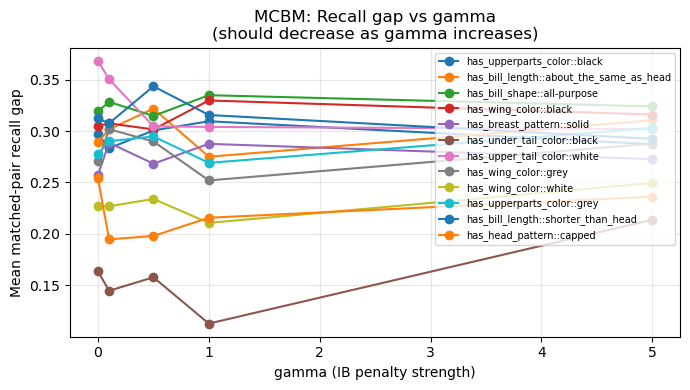

Saved mcbm_recall_gap_vs_gamma.png


In [25]:
# Plot: mean recall gap vs gamma, grouped by attribute.
# Central prediction: recall gap should decrease as gamma increases.

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))

for attr in ATTR_LIST:
    gaps = []
    for g in GAMMAS:
        info, _, _ = mcbm_results[g]
        row = info[info["attr"] == attr]
        mean_gap = float(row["mean_gap"].iloc[0]) if len(row) > 0 else float("nan")
        gaps.append(mean_gap)
    ax.plot(GAMMAS, gaps, marker="o", label=attr)

ax.set_xlabel("gamma (IB penalty strength)")
ax.set_ylabel("Mean matched-pair recall gap")
ax.set_title("MCBM: Recall gap vs gamma\n(should decrease as gamma increases)")
ax.legend(fontsize=7, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("mcbm_recall_gap_vs_gamma.png", dpi=150)
plt.show()
print("Saved mcbm_recall_gap_vs_gamma.png")

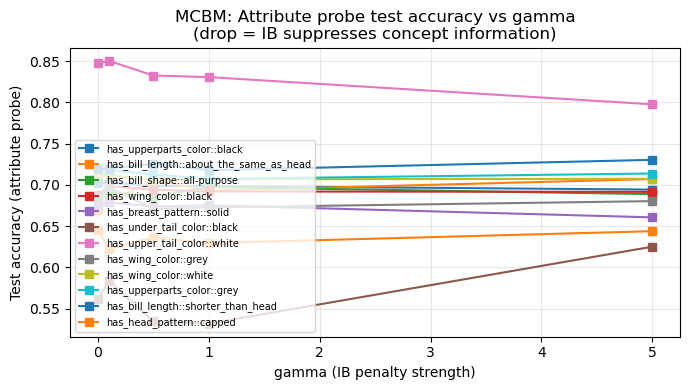

Saved mcbm_testacc_vs_gamma.png


In [26]:
# Plot: attribute probe test accuracy vs gamma.
# Answers: does stronger IB (larger gamma) degrade concept classification?
# Complements the recall-gap plot above.

fig, ax = plt.subplots(figsize=(7, 4))

for attr in ATTR_LIST:
    accs = []
    for g in GAMMAS:
        info, _, _ = mcbm_results[g]
        row = info[info["attr"] == attr]
        accs.append(float(row["test_acc"].iloc[0]) if len(row) > 0 else float("nan"))
    ax.plot(GAMMAS, accs, marker="s", label=attr)

ax.set_xlabel("gamma (IB penalty strength)")
ax.set_ylabel("Test accuracy (attribute probe)")
ax.set_title("MCBM: Attribute probe test accuracy vs gamma\n"
             "(drop = IB suppresses concept information)")
ax.legend(fontsize=7, loc="lower left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("mcbm_testacc_vs_gamma.png", dpi=150)
plt.show()
print("Saved mcbm_testacc_vs_gamma.png")


In [27]:
def top_pairs(pairs_df: pd.DataFrame, model: str, attr: str, k=10):
    """
    Filters to (model, attr), sorts by gap_mean descending, returns top-k pairs.
    Mirrors recall.ipynb cell 28.

    Columns:
      gap_mean/ci_lo/ci_hi : bootstrap estimate + 95 % CI
      gap_p     : two-sided p-value for H0: gap == 0
      gap_std   : variability across runs
      gap_snr   : mean gap / std gap
      gap_norm  : gap_mean on 0..1 scale
      npos/nneg : matched set sizes (identical for both species)
      n_runs    : number of bootstrap resampling runs
    """
    sub = pairs_df[(pairs_df["model"] == model) & (pairs_df["attr"] == attr)].copy()
    if sub.empty:
        return sub
    cols = [
        "species_A", "species_B",
        "gap_mean", "gap_ci_lo", "gap_ci_hi", "gap_p",
        "gap_std", "gap_snr", "gap_norm",
        "npos", "nneg", "n_runs",
    ]
    cols = [c for c in cols if c in sub.columns]
    return sub.sort_values("gap_mean", ascending=False).head(k)[cols]


### How confidence intervals and p-values are computed

For each species pair and attribute, we run the matched-pair evaluation multiple times
(`B_gap` runs, different random seeds). Each run produces one recall gap value.
These form an *empirical sampling distribution* of the recall gap.

#### Bootstrap CI (95 %)

- `gap_ci_lo` = 2.5th percentile of gap values across runs
- `gap_ci_hi` = 97.5th percentile of gap values across runs
- If the interval **excludes 0**, the gap is stable under resampling.

#### Bootstrap p-value

- H₀: recall gap = 0 (two-sided)
- `p = 2 × min(P(gap ≤ 0), P(gap ≥ 0))`
- A gap is **significant** if `gap_p ≤ 0.05` *and* the CI excludes 0.

Note: the bootstrap distribution reflects variability from *matched resampling*,
not independent image-level noise — no parametric assumptions needed.


In [28]:
# Top species pairs per attribute and gamma.
# Mirrors recall.ipynb cell 28: top_pairs loop with display().
# Shows which species pairs have the most species-dependent recall (worst entanglement).

for g in GAMMAS:
    _, pairs, _ = mcbm_results[g]
    if pairs.empty:
        print(f"gamma={g}: no pairs data")
        continue
    pairs_enr = add_gap_interpretability_cols(pairs)
    print(f"\n{'='*60}")
    print(f"  Top species pairs   gamma = {g}")
    print(f"{'='*60}")
    for attr in ATTR_LIST:
        print(f"\nAttribute: {attr}")
        display(top_pairs(pairs_enr, f"mcbm_gamma{g}", attr, k=5))



  Top species pairs   gamma = 0.0

Attribute: has_upperparts_color::black


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,nneg,n_runs
0,Rose breasted Grosbeak,Yellow Warbler,1.000000,1.000000,1.000000,0.0,0.000000,NaN,1.000000,15,10,100
1,Rose breasted Grosbeak,Prairie Warbler,0.923077,0.923077,0.923077,0.0,0.000000,NaN,0.923077,13,10,100
2,Canada Warbler,Pied Kingfisher,0.900000,0.900000,0.900000,0.0,0.000000,NaN,0.900000,10,10,100
3,Canada Warbler,Brewer Blackbird,0.847000,0.800000,0.900000,0.0,0.050161,16.885509,0.847000,10,11,100
4,Pied Kingfisher,Great Grey Shrike,0.823529,0.823529,0.823529,0.0,0.000000,NaN,0.823529,17,10,100



Attribute: has_bill_length::about_the_same_as_head


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,nneg,n_runs
198,Western Grebe,Orchard Oriole,0.933333,0.933333,0.933333,0.0,0.000000,NaN,0.933333,15,14,100
199,Long tailed Jaeger,Orchard Oriole,0.933333,0.933333,0.933333,0.0,0.000000,NaN,0.933333,15,14,100
200,Baltimore Oriole,Western Grebe,0.909091,0.909091,0.909091,0.0,0.000000,NaN,0.909091,11,14,100
201,Horned Puffin,Orchard Oriole,0.862143,0.857143,0.928571,0.0,0.018317,47.068935,0.862143,14,14,100
202,Louisiana Waterthrush,Orchard Oriole,0.828000,0.800000,0.900000,0.0,0.045126,18.348589,0.828000,10,14,100



Attribute: has_bill_shape::all-purpose


...

,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,nneg,n_runs
1754,Blue headed Vireo,Bobolink,0.854545,0.727273,1.000000,0.0,0.080693,10.590053,0.854545,11,11,100
1755,Northern Flicker,White breasted Nuthatch,0.818182,0.818182,0.818182,0.0,0.000000,NaN,0.818182,11,10,100
1756,White breasted Nuthatch,Sooty Albatross,0.818182,0.818182,0.818182,0.0,0.000000,NaN,0.818182,11,10,100
1757,Louisiana Waterthrush,Hooded Warbler,0.800000,0.800000,0.800000,0.0,0.000000,NaN,0.800000,10,18,100
1758,Louisiana Waterthrush,Wilson Warbler,0.769167,0.750000,0.833333,0.0,0.035246,21.822777,0.769167,12,17,100



Attribute: has_bill_length::shorter_than_head


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,nneg,n_runs
1952,Blue headed Vireo,Long tailed Jaeger,1.000000,1.000000,1.000000,0.0,0.000000,NaN,1.000000,15,10,100
1954,Orchard Oriole,Horned Puffin,0.846154,0.846154,0.846154,0.0,0.000000,NaN,0.846154,13,16,100
1953,Long tailed Jaeger,Orchard Oriole,0.846154,0.846154,0.846154,0.0,0.000000,NaN,0.846154,13,15,100
1955,Cerulean Warbler,Long tailed Jaeger,0.832667,0.800000,0.933333,0.0,0.041838,19.902307,0.832667,15,12,100
1956,White necked Raven,Blue headed Vireo,0.818182,0.818182,0.818182,0.0,0.000000,NaN,0.818182,11,10,100



Attribute: has_head_pattern::capped


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,nneg,n_runs
2147,Forsters Tern,Gray Catbird,0.642857,0.642857,0.642857,0.0,0.000000,NaN,0.642857,14,10,100
2148,Gray Catbird,Common Tern,0.636923,0.615385,0.692308,0.0,0.034596,18.410265,0.636923,13,15,300
2149,Common Tern,Gray Catbird,0.636923,0.615385,0.692308,0.0,0.034712,18.348589,0.636923,13,15,100
2150,Artic Tern,Western Grebe,0.583333,0.583333,0.583333,0.0,0.000000,NaN,0.583333,12,15,100
2151,Western Grebe,Forsters Tern,0.583333,0.583333,0.583333,0.0,0.000000,NaN,0.583333,12,10,100


## 5d. Layer sweep, attribute emergence, and entanglement signal

**Why sweep all 18 layers here?**
The three entanglement plots below require knowing *when* each attribute becomes
linearly decodable — its emergence layer. This needs probe accuracy at every layer.
In `recall.ipynb` only `layer4.0` was used because the focus was entanglement at one
point; here we add the full sweep as an optional extension.

**Balanced vs plain accuracy**
`use_balanced_acc=True` computes 0.5·(TPR + TNR) instead of raw correct/total.
This is robust to class imbalance — for an attribute present in 15% of images,
predicting all-negative gives 85% plain accuracy for free, but only 50% balanced.
`run_one_attribute` and `run_many` both now accept `use_balanced_acc` (default False
for backward compatibility with previously saved results).

**Species emergence layer:** `layer4.0` = index 14 in the LAYERS list.
Taken from the sharp-jump species emergence analysis in `lfcbm_newrecall.ipynb`.

**Pre / At / Post grouping:**
- **pre**  emergence_idx < 14: probe can detect attribute without species-level cues
- **at**   emergence_idx = 14: attribute and species emerge simultaneously
- **post** emergence_idx > 14: attribute only decodable after species representations form

**Central prediction:** POST attributes should show larger matched-pair recall gaps —
their visual evidence is entangled with the species-level representations that form at layer4.0.


In [29]:
LAYERS = [
    "conv1",
    "layer1.0", "layer1.1", "layer1.2",
    "layer2.0", "layer2.1", "layer2.2", "layer2.3",
    "layer3.0", "layer3.1", "layer3.2", "layer3.3", "layer3.4", "layer3.5",
    "layer4.0", "layer4.1", "layer4.2",
    "avgpool",
]
SPECIES_LAYER_IDX = 14  # layer4.0 — species sharp-jump emergence (lfcbm_newrecall.ipynb)
LAYER_TO_IDX = {l: i for i, l in enumerate(LAYERS)}

def sharp_jump_idx(vals):
    """Index of the largest single-step increase in a layerwise accuracy curve."""
    v = np.asarray(vals, dtype=float)
    return int(np.argmax(np.diff(v))) + 1

def frac_of_final_idx(vals, frac=0.90):
    """First layer index where the curve reaches `frac` x its final value."""
    v = np.asarray(vals, dtype=float)
    target = frac * v[-1]
    idxs = np.where(v >= target)[0]
    return int(idxs[0]) if len(idxs) else len(v) - 1


In [30]:
def compute_emergence_for_attr(
    attr_name: str,
    feat_dir: Path,
    kind_tr: str, ids_tr: np.ndarray,
    kind_te: str, ids_te: np.ndarray,
    *,
    use_balanced_acc: bool = True,
    epochs: int = 6,
):
    """
    Trains a probe at each of the 18 LAYERS and returns the layerwise accuracy curve.
    Matched-pair analysis is skipped (n_pairs=0) — this is emergence detection only.

    Returns:
      curve      : list of 18 floats (accuracy at each layer)
      sharp_jump : index of largest single-step jump in the curve
      frac90     : first index reaching 90% of final accuracy
    """
    curve = []
    for layer in LAYERS:
        info, _, _, _, _ = run_one_attribute(
            attr_name, feat_dir, kind_tr, ids_tr, kind_te, ids_te,
            layer=layer,
            epochs=epochs,
            n_pairs=0,
            B_species=0,
            B_gap=0,
            use_balanced_acc=use_balanced_acc,
        )
        curve.append(info["test_acc"])

    sj  = sharp_jump_idx(curve)
    f90 = frac_of_final_idx(curve, frac=0.90)
    return curve, sj, f90


In [31]:
def screen_and_compute_emergence(
    candidate_attrs,
    feat_dir: Path,
    kind_tr: str, ids_tr: np.ndarray,
    kind_te: str, ids_te: np.ndarray,
    *,
    use_balanced_acc: bool = True,
    epochs: int = 6,
    max_attrs: int = 312,
    verbose_every: int = 25,
) -> pd.DataFrame:
    """
    Runs a layer sweep for each candidate attribute.
    Attributes that raise exceptions are silently skipped.

    Returns DataFrame columns: attr, sharp_jump_idx, frac90_idx, final_acc
    """
    rows = []
    cands = list(candidate_attrs)[:max_attrs]

    for i, attr in enumerate(cands):
        try:
            curve, sj, f90 = compute_emergence_for_attr(
                attr, feat_dir, kind_tr, ids_tr, kind_te, ids_te,
                use_balanced_acc=use_balanced_acc, epochs=epochs,
            )
            rows.append({
                "attr": attr,
                "sharp_jump_idx": sj,
                "frac90_idx": f90,
                "final_acc": float(curve[-1]),
            })
        except Exception:
            pass

        if verbose_every and (i + 1) % verbose_every == 0:
            print(f"  [{i+1}/{len(cands)}] done  (kept so far: {len(rows)})")

    df = pd.DataFrame(rows)
    print(f"\nEmergence sweep complete: {len(df)}/{len(cands)} attrs kept.")
    return df


In [32]:
# ── Run emergence sweep ───────────────────────────────────────────────────────
# Uses gamma=0.0 features (most informative, least IB compression).
#
# Runtime guidance:
#   EMERGENCE_MAX_ATTRS=5   -> ~30 s  (smoke test)
#   EMERGENCE_MAX_ATTRS=50  -> ~5 min
#   EMERGENCE_MAX_ATTRS=312 -> ~30-60 min  (publication quality, all CUB attrs)
#
# EMERGENCE_BALANCED=True uses balanced accuracy (recommended — robust to imbalance).

EMERGENCE_MAX_ATTRS = 312   # lower for a quick test
EMERGENCE_BALANCED  = True
EMERGENCE_EPOCHS    = 6

CANDIDATE_ATTRS = attr_df["attr_name"].tolist()

emergence_df = screen_and_compute_emergence(
    CANDIDATE_ATTRS,
    MCBM_FEATS[0.0],
    mcbm_kind_tr, mcbm_ids_tr,
    mcbm_kind_te, mcbm_ids_te,
    use_balanced_acc=EMERGENCE_BALANCED,
    epochs=EMERGENCE_EPOCHS,
    max_attrs=EMERGENCE_MAX_ATTRS,
    verbose_every=25,
)
emergence_df.head(10)


  [25/312] done  (kept so far: 25)
  [50/312] done  (kept so far: 50)
  [75/312] done  (kept so far: 75)
  [100/312] done  (kept so far: 100)
  [125/312] done  (kept so far: 125)
  [150/312] done  (kept so far: 150)
  [175/312] done  (kept so far: 175)
  [200/312] done  (kept so far: 200)
  [225/312] done  (kept so far: 225)
  [250/312] done  (kept so far: 250)
  [275/312] done  (kept so far: 275)
  [300/312] done  (kept so far: 300)

Emergence sweep complete: 312/312 attrs kept.


,attr,sharp_jump_idx,frac90_idx,final_acc
0,has_bill_shape::curved_(up_or_down),14,14,0.701973
1,has_bill_shape::dagger,14,14,0.735276
2,has_bill_shape::hooked,13,14,0.637356
3,has_bill_shape::needle,14,14,0.804235
4,has_bill_shape::hooked_seabird,8,8,0.857375
5,has_bill_shape::spatulate,14,4,0.849781
6,has_bill_shape::all-purpose,14,14,0.704270
7,has_bill_shape::cone,14,14,0.737557
8,has_bill_shape::specialized,14,14,0.785039
9,has_wing_color::blue,14,14,0.869005


In [ ]:
# ── Recall gap analysis for all emerged attributes at layer4.0 ────────────────
# Run for every gamma so we can compare whether backwash reduces entanglement.
# Fewer pairs/bootstraps than the main analysis for speed.

entanglement_results = {}
for g in GAMMAS:
    print(f"\nRunning recall gap for gamma={g} ...")
    info_g, pairs_g, species_g = run_many(
        emergence_df["attr"].tolist(),
        f"mcbm_g{g}_full",
        MCBM_FEATS[g],
        mcbm_kind_tr, mcbm_ids_tr,
        mcbm_kind_te, mcbm_ids_te,
        layer="layer4.0",
        epochs=25,
        n_pairs=100,
        B_gap=50,
        B_species=50,
        use_balanced_acc=EMERGENCE_BALANCED,
    )
    entanglement_results[g] = (info_g, pairs_g, species_g)
    print(f"  gamma={g}: {len(info_g)} attrs, {len(pairs_g)} pair rows")

print("\nAll gammas done.")



Running recall gap for gamma=0.0 ...
mcbm_g0.0_full has_bill_shape::curved_(up_or_down) bal_acc= 0.6256 mean_gap= 0.014
mcbm_g0.0_full has_bill_shape::dagger bal_acc= 0.7117 mean_gap= 0.2531
mcbm_g0.0_full has_bill_shape::hooked bal_acc= 0.5742 mean_gap= nan
mcbm_g0.0_full has_bill_shape::needle bal_acc= 0.7964 mean_gap= nan
mcbm_g0.0_full has_bill_shape::hooked_seabird bal_acc= 0.8528 mean_gap= 0.0976


In [ ]:
# ── Merge emergence + recall gap; classify pre / at / post (all gammas) ───────
CRITERION = "sharp_jump_idx"   # change to "frac90_idx" to switch criterion

all_gap_rows = []
for g, (info_g, pairs_g, _) in entanglement_results.items():
    gdf = (
        info_g[["attr", "mean_gap"]]
        .merge(emergence_df[["attr", CRITERION]], on="attr")
    )
    gdf["gamma"] = g
    gdf["group"] = gdf[CRITERION].apply(
        lambda x: "pre" if x < SPECIES_LAYER_IDX
                  else ("at" if x == SPECIES_LAYER_IDX else "post")
    )
    if not pairs_g.empty:
        pair_frac = (
            pairs_g.groupby("attr")["gap_ci_lo"]
            .apply(lambda s: float((np.asarray(s) > 0).mean()))
            .reset_index(name="frac_ci_above0")
        )
        gdf = gdf.merge(pair_frac, on="attr", how="left")
    else:
        gdf["frac_ci_above0"] = float("nan")
    gdf["discriminative"] = gdf["frac_ci_above0"] > 0.5
    all_gap_rows.append(gdf)

all_gap_df = pd.concat(all_gap_rows, ignore_index=True)

# Baseline (gamma=0.0) view for the original 3-panel plots
gap_info = all_gap_df[all_gap_df["gamma"] == 0.0].copy()

print("Group counts (gamma=0.0):", dict(gap_info["group"].value_counts()))
print("All gammas shape:", all_gap_df.shape)
gap_info.head()


In [ ]:
# ── Entanglement signal plots (3 baseline + 1 cross-gamma summary) ────────────
import matplotlib.pyplot as plt

GROUP_COLORS = {"pre": "steelblue", "at": "orange", "post": "crimson"}
GROUP_ORDER  = ["pre", "at", "post"]

# ── 3-panel baseline plot (gamma=0.0) ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
for g in GROUP_ORDER:
    vals = gap_info[gap_info["group"] == g]["mean_gap"].dropna().sort_values()
    n = len(vals)
    if n == 0:
        continue
    ax.plot(vals.values, np.arange(1, n + 1) / n,
            color=GROUP_COLORS[g], label=f"{g} (n={n})", lw=2)
ax.axvline(0.05, color="gray", ls="--", alpha=0.5)
ax.set_xlabel("Mean matched-pair recall gap")
ax.set_ylabel("Cumulative fraction of concepts")
ax.set_title(f"ECDF of recall gaps by group\n(POST right-shifted = entanglement signal)")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
for i, g in enumerate(GROUP_ORDER):
    sub = gap_info[gap_info["group"] == g]
    n = len(sub)
    frac = float(sub["discriminative"].mean()) if n > 0 else 0.0
    ax.bar(i, frac, color=GROUP_COLORS[g])
    ax.text(i, frac + 0.02, f"n={n}", ha="center", fontsize=9)
ax.axhline(0.5, color="gray", ls="--", alpha=0.7, label="50% line")
ax.set_xticks(range(3)); ax.set_xticklabels(GROUP_ORDER)
ax.set_ylabel("Fraction of concepts\n(>50% pairs: CI entirely above 0)")
ax.set_title("Proportion discriminative by group\n(what we actually care about)")
ax.legend(); ax.grid(True, alpha=0.3, axis="y"); ax.set_ylim(0, 1.15)

ax = axes[2]
for g in GROUP_ORDER:
    sub = gap_info[gap_info["group"] == g]
    ax.scatter(sub[CRITERION], sub["mean_gap"],
               color=GROUP_COLORS[g], alpha=0.6, s=40, label=f"{g} (n={len(sub)})")
v2 = gap_info[[CRITERION, "mean_gap"]].dropna()
if len(v2) > 1:
    m, b = np.polyfit(v2[CRITERION], v2["mean_gap"], 1)
    xs = np.array([v2[CRITERION].min(), v2[CRITERION].max()])
    ax.plot(xs, m * xs + b, "k--", label=f"trend (slope={m:.4f})")
ax.axvline(SPECIES_LAYER_IDX, color="gray", ls=":", label="species layer (layer4.0)")
ax.set_xlabel(f"Concept emergence layer index ({CRITERION})")
ax.set_ylabel("Mean matched-pair recall gap")
ax.set_title("Later-emerging -> larger gaps?\n(continuous, no binning)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle(
    f"Entanglement signal (gamma=0.0 baseline): recall gap vs. emergence timing\n"
    f"(cbm — criterion: {CRITERION}, n_attrs={len(gap_info)})",
    y=1.02,
)
plt.tight_layout()
plt.savefig("mcbm_entanglement_signal_g0.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved mcbm_entanglement_signal_g0.png")

# ── Cross-gamma summary: does backwash reduce entanglement? ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel A: mean recall gap vs gamma, by pre/at/post group
ax = axes[0]
for g in GROUP_ORDER:
    sub = all_gap_df[all_gap_df["group"] == g]
    means = sub.groupby("gamma")["mean_gap"].mean()
    sems  = sub.groupby("gamma")["mean_gap"].sem()
    ax.errorbar(means.index, means.values, yerr=sems.values,
                marker="o", label=g, color=GROUP_COLORS[g], capsize=4)
ax.set_xlabel("gamma (IB penalty strength)")
ax.set_ylabel("Mean recall gap (mean ± SEM across concepts)")
ax.set_title("Does backwash reduce entanglement?\n(hypothesis: post line slopes down)")
ax.legend(); ax.grid(True, alpha=0.3)

# Panel B: fraction discriminative vs gamma, by group
ax = axes[1]
for g in GROUP_ORDER:
    sub = all_gap_df[all_gap_df["group"] == g]
    fracs = sub.groupby("gamma")["discriminative"].mean()
    ax.plot(fracs.index, fracs.values, marker="s", label=g, color=GROUP_COLORS[g])
ax.axhline(0.5, color="gray", ls="--", alpha=0.6, label="50% line")
ax.set_xlabel("gamma (IB penalty strength)")
ax.set_ylabel("Fraction discriminative")
ax.set_title("Fraction discriminative vs gamma")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1.05)

plt.suptitle("MCBM backwash effect on recall gap entanglement signal", y=1.02)
plt.tight_layout()
plt.savefig("mcbm_entanglement_vs_gamma.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved mcbm_entanglement_vs_gamma.png")


## 6. Cross-model comparison table

Aggregates the per-species recall tables from all four models into a single
comparison dataframe:

| Model | Description |
|---|---|
| `baseline` | ResNet-50 fine-tuned for species only (no concept supervision) |
| `cbm` | SimpleCBM — ResNet-50, concept-supervised, no IB |
| `lfcbm` | Label-Free CBM — CLIP-derived concepts |
| `mcbm_γ=X` | MCBM at each IB strength (this notebook) |

> **Dependency:** requires `sub_species.csv` from the parallel SUB evaluation
> session. Uncomment the `sub` row once that file is available.

In [ ]:
# ── DEPENDENCY NOTE ─────────────────────────────────────────────────────────
# This cell requires notebooks/sub_species.csv produced by the parallel
# SUB evaluation session (features/resnet50_sub/, scripts/train_sub.py).
# That session runs independently on Adroit and has no path overlap with MCBM.
# Once sub_species.csv is available, uncomment the "sub" row below.
# ─────────────────────────────────────────────────────────────────────────────

# Aggregate species recall tables from all models into one comparison dataframe.

dfs = []
for name, path in [
    ("baseline", "baseline_species.csv"),
    ("cbm",      "cbm_species.csv"),
    ("lfcbm",    "lfcbm_species.csv"),
    # ("sub",    "sub_species.csv"),  # TODO: uncomment when SUB session completes
]:
    dfs.append(pd.read_csv(path).assign(model=name))

for g in GAMMAS:
    dfs.append(
        pd.read_csv(f"mcbm_species_gamma{g}.csv").assign(model=f"mcbm_gamma{g}")
    )

all_df = pd.concat(dfs, ignore_index=True)

# Summary: mean recall by (model, attr)
summary = (
    all_df.groupby(["model", "attr"])["recall"]
    .mean()
    .reset_index()
    .rename(columns={"recall": "mean_recall"})
    .sort_values(["attr", "model"])
)
print(summary.to_string())
summary